<h1 style="color: white; 
           background-color: black; 
           font-family: 'Algerian', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   UPI_Transaction_Analysis
</h1>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
pd.set_option('display.max_columns', None)

# Load datasets

In [3]:
customer_master = pd.read_csv("../Data_Set/customer_master.csv")
device_info = pd.read_csv("../Data_Set/device_info.csv")
upi_account_details = pd.read_csv("../Data_Set/upi_account_details.csv")
merchant_info = pd.read_csv("../Data_Set/merchant_info.csv")
upi_transaction_history = pd.read_csv("../Data_Set/upi_transaction_history.csv")
customer_feedback_surveys = pd.read_csv("../Data_Set/customer_feedback_surveys.csv")
fraud_alert_history = pd.read_csv("../Data_Set/fraud_alert_history.csv")

# Understanding the Dataset Structure

In [50]:
datasets = {
    "customer_master": customer_master,
    "device_info": device_info,
    "upi_account_details": upi_account_details,
    "merchant_info": merchant_info,
    "upi_transaction_history": upi_transaction_history,
    "customer_feedback_surveys": customer_feedback_surveys,
    "fraud_alert_history": fraud_alert_history
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.info())


customer_master
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  str    
 1   full_name         10000 non-null  str    
 2   mobile_number     10000 non-null  int64  
 3   age               10000 non-null  int64  
 4   gender            10000 non-null  str    
 5   region            10000 non-null  str    
 6   date_joined       10000 non-null  str    
 7   is_business_user  10000 non-null  bool   
 8   risk_score        10000 non-null  float64
dtypes: bool(1), float64(1), int64(2), str(5)
memory usage: 634.9 KB
None

device_info
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   device_id    12000 non-null  str  
 1   customer_id  12000 non-null  str  
 2   device_type  12000 no

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>Dataset Understanding:</h4>
<ul>
<li>Total 7 datasets were used in the project.</li>
<li>The data includes customer, transaction, merchant, device, and fraud information.</li>
<li>The transaction dataset contains 100K+ records.</li>
<li>The datasets are relational and suitable for advanced analytics.</li>
</ul>
</body>
</body></html>



# Duplicate Records Analysis

In [51]:
for name, df in datasets.items():
    print(f"{name} Duplicate Rows :", df.duplicated().sum())

customer_master Duplicate Rows : 0
device_info Duplicate Rows : 0
upi_account_details Duplicate Rows : 0
merchant_info Duplicate Rows : 0
upi_transaction_history Duplicate Rows : 0
customer_feedback_surveys Duplicate Rows : 0
fraud_alert_history Duplicate Rows : 0


<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>No major duplicate records were identified across the datasets, indicating good data consistency and integrity.</h4>

</body>
</body></html>

# Data Type Inspection

In [52]:
for name, df in datasets.items():
    print("\n", "="*50)
    print(name)
    print("="*50)
    print(df.dtypes)


customer_master
customer_id             str
full_name               str
mobile_number         int64
age                   int64
gender                  str
region                  str
date_joined             str
is_business_user       bool
risk_score          float64
dtype: object

device_info
device_id       str
customer_id     str
device_type     str
app_version     str
is_rooted      bool
last_active     str
dtype: object

upi_account_details
upi_id          str
customer_id     str
bank_name       str
account_type    str
date_added      str
status          str
dtype: object

merchant_info
merchant_id          str
merchant_name        str
merchant_type        str
region               str
onboard_date         str
risk_score       float64
dtype: object

upi_transaction_history
transaction_id          str
upi_id                  str
customer_id             str
timestamp               str
amount              float64
transaction_type        str
merchant_id             str
counterparty_up

# Datetime Conversion

In [53]:
upi_transaction_history['timestamp'] = pd.to_datetime(
    upi_transaction_history['timestamp']
)

customer_master['date_joined'] = pd.to_datetime(
    customer_master['date_joined']
)

upi_account_details['date_added'] = pd.to_datetime(
    upi_account_details['date_added']
)

fraud_alert_history['alert_date'] = pd.to_datetime(
    fraud_alert_history['alert_date']
)

fraud_alert_history['resolution_date'] = pd.to_datetime(
    fraud_alert_history['resolution_date']
)

# Feature Engineering

In [54]:
upi_transaction_history['transaction_year'] = upi_transaction_history['timestamp'].dt.year

upi_transaction_history['transaction_month'] = upi_transaction_history['timestamp'].dt.month

upi_transaction_history['transaction_day'] = upi_transaction_history['timestamp'].dt.day

upi_transaction_history['transaction_hour'] = upi_transaction_history['timestamp'].dt.hour

upi_transaction_history['transaction_weekday'] = upi_transaction_history['timestamp'].dt.day_name()

# Transaction Amount Segmentation

In [55]:
def amount_category(x):
    
    if x < 500:
        return "Low"
    
    elif x < 5000:
        return "Medium"
    
    else:
        return "High"


upi_transaction_history['amount_category'] = (
    upi_transaction_history['amount']
    .apply(amount_category)
)

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>Transactions were categorized into Low, Medium, and High-value segments to better analyze customer payment behavior and fraud exposure across transaction ranges.</h4>

</body>
</body></html>


# Fraud Risk Labeling

In [56]:
upi_transaction_history['fraud_label'] = (
    upi_transaction_history['fraud_flag']
    .map({True: "Fraud", False: "Legitimate"})
)

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>Transactions were classified into Fraud and Legitimate categories using the fraud_flag variable. 
This labeling helps identify suspicious transaction patterns, compare fraudulent and normal customer behavior, and support fraud risk analysis across devices, merchants, and transaction types.</h4>

</body>
</body></html>


# Custom First 10 Rows


In [ ]:
upi_transaction_history.head(10)

<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
   Transaction Status Distribution
</h3>

In [57]:
upi_transaction_history['status'].value_counts()

status
success    92140
failed      5871
pending     1989
Name: count, dtype: int64

<h3 style="color: yellow; 
           background-color: gray; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   Visualization Stage
</h3>

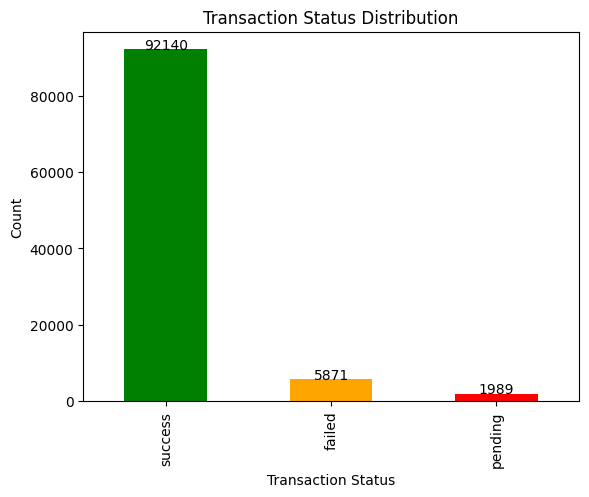

In [58]:
ax = upi_transaction_history['status'].value_counts().plot(
    kind='bar',
    color=['green','orange','red']
)

plt.title("Transaction Status Distribution")
plt.xlabel("Transaction Status")
plt.ylabel("Count")

for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width()/2,
        i.get_height(),
        int(i.get_height()),
        ha='center'
    )

plt.show()

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>The majority of UPI transactions were successfully completed, accounting for more than 92% of total transactions. 
Failed transactions represented a smaller proportion, indicating occasional technical or operational issues, while pending transactions were minimal, reflecting overall stable transaction processing performance.</h4>

</body>
</body></html>



<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
   Fraudulent Transaction Analysis
</h3>

In [ ]:
upi_transaction_history['fraud_label'].value_counts()

<h3 style="color: yellow; 
           background-color: gray; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   Visualization Stage
</h3>

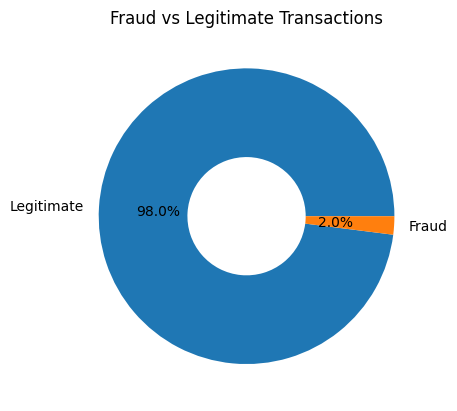

In [59]:
upi_transaction_history['fraud_label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    wedgeprops={'width':0.6}
)

plt.title("Fraud vs Legitimate Transactions")

plt.ylabel("")

plt.show()

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>Approximately 98% of transactions were identified as legitimate, while only around 2% were flagged as fraudulent. 
This indicates that the UPI ecosystem is largely secure and stable; however, even a small percentage of fraud can lead to significant financial and operational risks due to the high transaction volume.</h4>

</body>
</body></html>



<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
  Transaction Amount Analysis
</h3>

In [60]:
counts, bins = np.histogram(
    upi_transaction_history['amount'],
    bins=25
)

for i in range(len(counts)):
    
    print(
        f"{bins[i]:.0f} - {bins[i+1]:.0f} : {counts[i]}"
    )

2 - 35 : 52836
35 - 68 : 31952
68 - 101 : 9625
101 - 134 : 3278
134 - 167 : 1279
167 - 201 : 495
201 - 234 : 255
234 - 267 : 125
267 - 300 : 67
300 - 333 : 33
333 - 366 : 18
366 - 399 : 8
399 - 433 : 4
433 - 466 : 6
466 - 499 : 6
499 - 532 : 4
532 - 565 : 2
565 - 598 : 2
598 - 632 : 1
632 - 665 : 0
665 - 698 : 2
698 - 731 : 0
731 - 764 : 0
764 - 797 : 1
797 - 830 : 1


<h3 style="color: yellow; 
           background-color: gray; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   Visualization Stage
</h3>

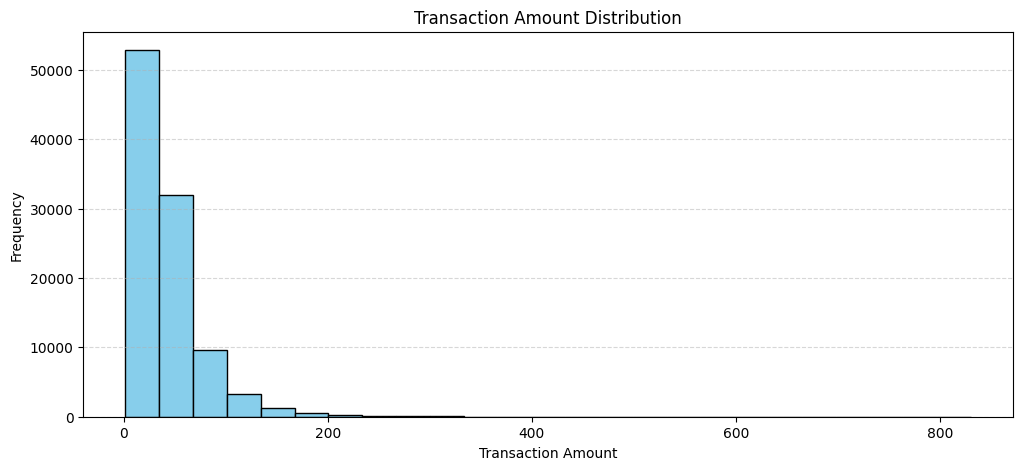

In [32]:
plt.figure(figsize=(12,5))

plt.hist(
    upi_transaction_history['amount'],
    bins=25,
    color='skyblue',
    edgecolor='black'
)

plt.title("Transaction Amount Distribution")

plt.xlabel("Transaction Amount")

plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>The majority of transactions were concentrated in the lower transaction amount ranges, with more than 52,000 transactions occurring between 2–35 units and around 31,000 transactions between 35–68 units. 

As the transaction amount increased, the transaction frequency declined significantly, indicating that customers primarily use UPI for small and medium-value payments while high-value transactions are comparatively rare.</h4>

</body>
</body></html>



<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
  Transaction Amount Category Distribution
</h3>

In [ ]:
upi_transaction_history['amount_category'].value_counts()

<h3 style="color: yellow; 
           background-color: gray; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   Visualization Stage
</h3>

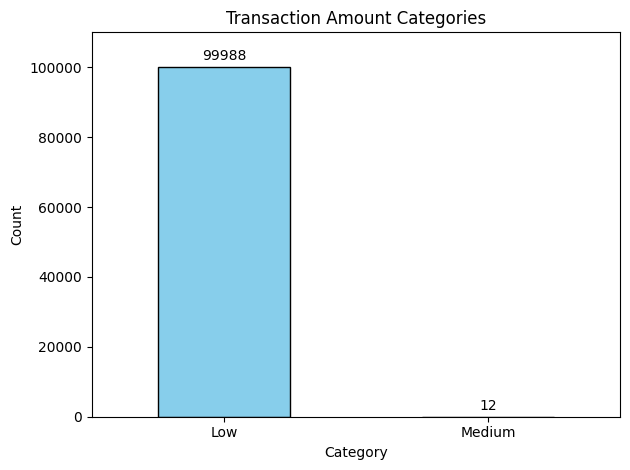

In [61]:
import matplotlib.pyplot as plt
ax = upi_transaction_history['amount_category'].value_counts().plot(
    kind='bar',
    color='skyblue',       
    edgecolor='black'      
)
ax.bar_label(ax.containers[0], padding=3)
plt.title("Transaction Amount Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=0) 
current_max = upi_transaction_history['amount_category'].value_counts().max()
plt.ylim(0, current_max + (current_max * 0.1)) 
plt.tight_layout()
plt.show()

<html>
    <body>
<h4>UPI usage is heavily dominated by low-value transactions, accounting for over 99.9% of the total volume. Medium-value transactions are extremely rare (only 12 counts), indicating that this account/dataset is almost exclusively used for small daily expenses.</h4>

</body>
</body></html>



<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
  Monthly Transaction Trend Analysis
</h3>

<h3 style="color: yellow; 
           background-color: gray; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   Visualization Stage
</h3>

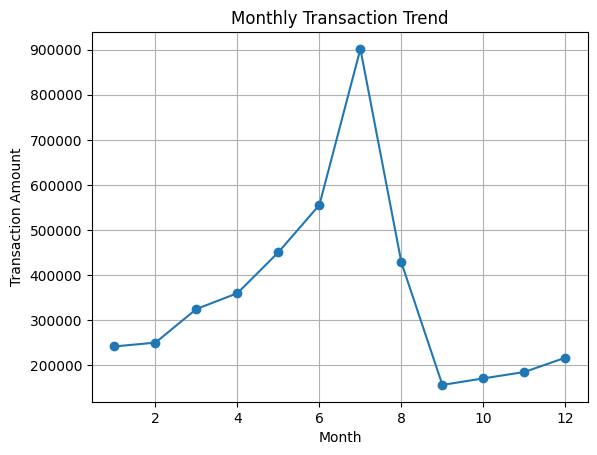

In [62]:
monthly_trend = upi_transaction_history.groupby(
    'transaction_month'
)['amount'].sum()

monthly_trend.plot(
    kind='line',
    marker='o'
)
plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Transaction Amount")
plt.grid()
plt.show()

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>Transaction activity increased steadily from Month 1 to Month 7, reaching the highest transaction volume in Month 7. After the peak, transaction activity declined sharply between Months 8 and 9 and remained relatively stable during the remaining months.

This pattern suggests a possible seasonal or campaign-driven increase in transactions during the middle of the year, followed by reduced customer transaction activity in later months.</h4>

</body>
</body></html>



<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
  Hourly Transaction Analysis
</h3>

<h3 style="color: yellow; 
           background-color: gray; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   Visualization Stage
</h3>

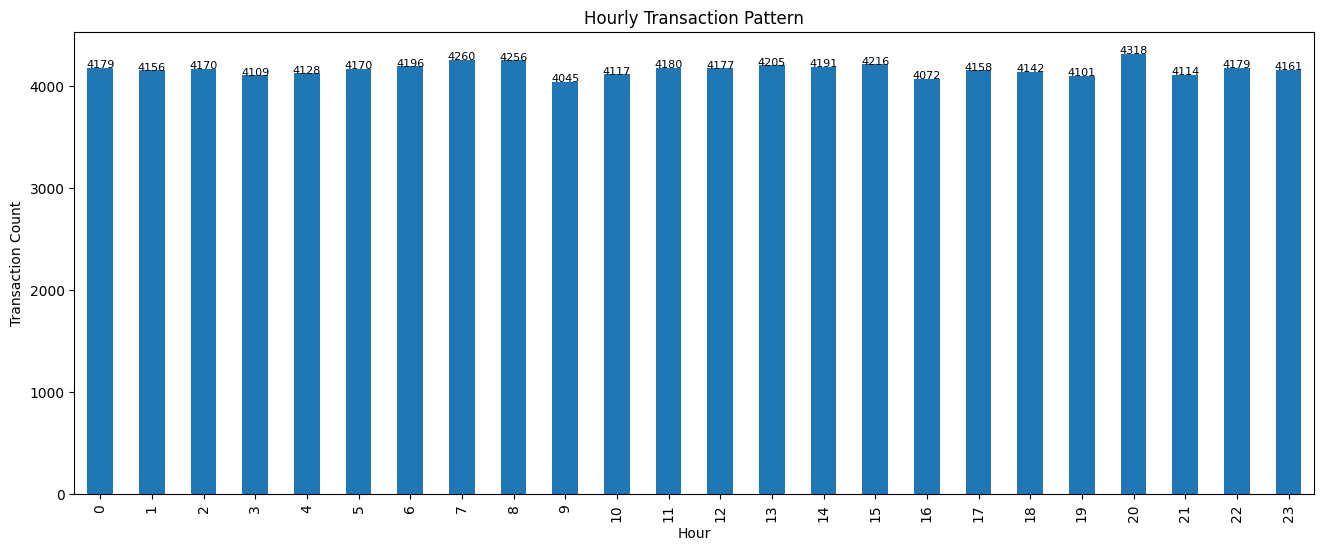

In [63]:
plt.figure(figsize=(16,6))

hourly_trend = upi_transaction_history[
    'transaction_hour'
].value_counts().sort_index()

ax = hourly_trend.plot(kind='bar')

plt.title("Hourly Transaction Pattern")

plt.xlabel("Hour")

plt.ylabel("Transaction Count")


for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width()/2,
        i.get_height(),
        int(i.get_height()),
        ha='center',
        fontsize=8
    )

plt.show()

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>Transaction activity remained relatively consistent throughout the day, with only minor fluctuations across different hours. Peak transaction activity was observed during a few hours, while no major drop in transaction volume was noticed, indicating stable customer engagement across the 24-hour period.</h4>

</body>
</body></html>



<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
  Weekday Transaction Analysis
</h3>

<h3 style="color: yellow; 
           background-color: gray; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   Visualization Stage
</h3>

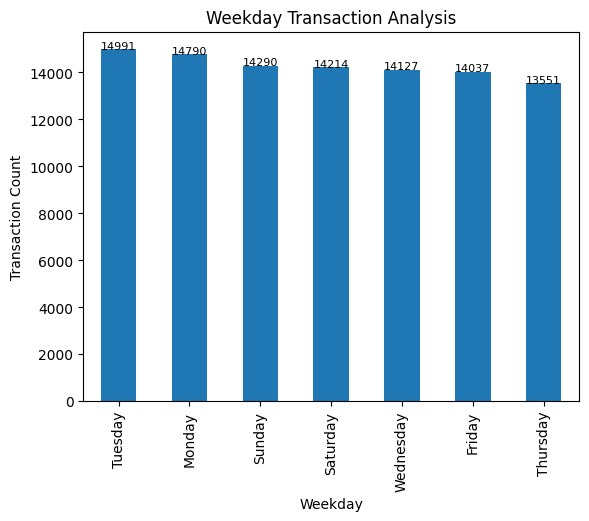

In [64]:
weekday_trend = upi_transaction_history[
    'transaction_weekday'
].value_counts()

ax = weekday_trend.plot(kind='bar')
plt.title("Weekday Transaction Analysis")
plt.xlabel("Weekday")
plt.ylabel("Transaction Count")

for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width()/2,
        i.get_height(),
        int(i.get_height()),
        ha='center',
        fontsize=8
    )

plt.show()

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>Transaction activity varied across weekdays, helping identify customer payment preferences and high-engagement transaction periods.</h4>

</body>
</body></html>



<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
  Fraud Analysis by Device Type
</h3>

<h3 style="color: yellow; 
           background-color: gray; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   Visualization Stage
</h3>

device_type
feature_phone    551
android          501
tablet           488
ios              460
Name: count, dtype: int64


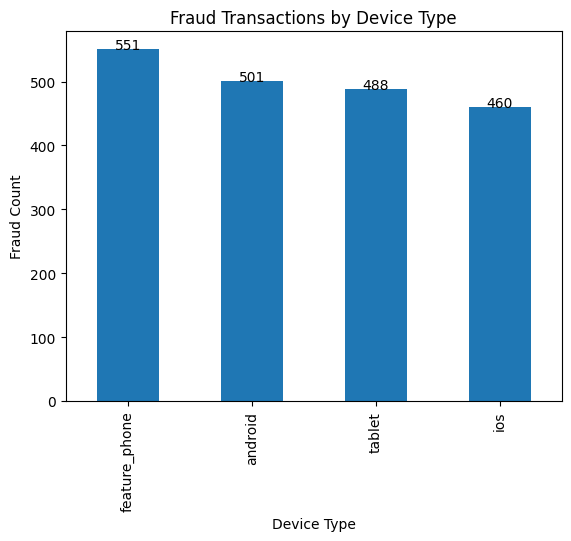

In [65]:
fraud_device = upi_transaction_history.loc[
    upi_transaction_history['fraud_flag'] == True,
    'device_type'
].value_counts()

print(fraud_device)

ax = fraud_device.plot(kind='bar')

plt.title("Fraud Transactions by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Fraud Count")

for i in ax.patches:
    ax.text(i.get_x() + i.get_width()/2, i.get_height(), int(i.get_height()), ha='center')

plt.show()

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>Feature phones recorded the highest number of fraudulent transactions, while iOS devices showed the lowest fraud count. This suggests varying fraud risk across different device types.</h4>

</body>
</body></html>



<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
  Fraud Analysis by Transaction Channel
</h3>

<h3 style="color: yellow; 
           background-color: gray; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   Visualization Stage
</h3>

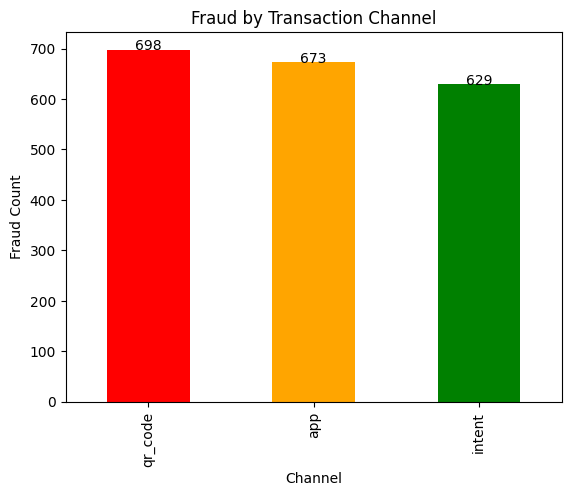

In [66]:
fraud_channel = upi_transaction_history[
    upi_transaction_history['fraud_label'] == 'Fraud'
]['channel'].value_counts()

ax = fraud_channel.plot(
    kind='bar',
    color=['red', 'orange', 'green', 'purple', 'skyblue']
)

plt.title("Fraud by Transaction Channel")
plt.xlabel("Channel")
plt.ylabel("Fraud Count")

for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width()/2,
        i.get_height(),
        int(i.get_height()),
        ha='center'
    )

plt.show()

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>Fraudulent transactions were distributed across all transaction channels, with QR code payments recording the highest number of fraud cases (698), followed closely by app-based transactions (673). Intent-based transactions showed comparatively lower fraud activity (629).

This suggests that QR code and app payment channels may require stronger fraud monitoring and additional authentication mechanisms to reduce suspicious transaction risks.</h4>

</body>
</body></html>



<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
  Fraud by Transaction Type
</h3>

<h3 style="color: yellow; 
           background-color: gray; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   Visualization Stage
</h3>

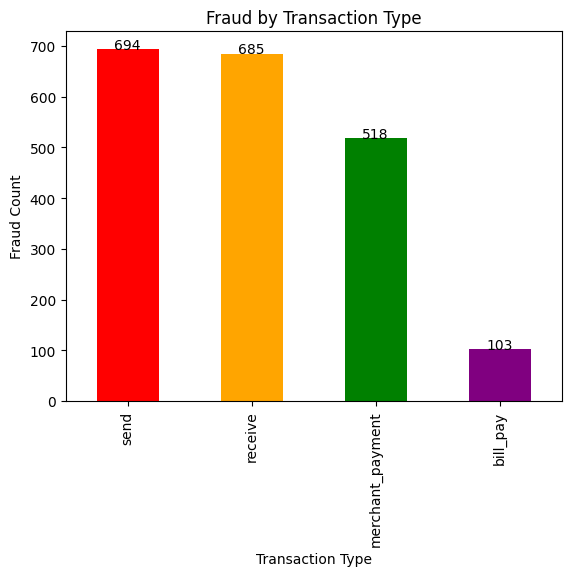

In [67]:
fraud_type = upi_transaction_history[
    upi_transaction_history['fraud_label'] == 'Fraud'
]['transaction_type'].value_counts()

ax = fraud_type.plot(
    kind='bar',
    color=['red', 'orange', 'green', 'purple', 'skyblue']
)

plt.title("Fraud by Transaction Type")

plt.xlabel("Transaction Type")

plt.ylabel("Fraud Count")


for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width()/2,
        i.get_height(),
        int(i.get_height()),
        ha='center'
    )

plt.show()

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>Fraudulent transactions were highest in send (694) and receive (685) transaction types, indicating that money transfer activities are more exposed to fraud risk. Merchant payment transactions also showed a noticeable number of fraud cases (518), while bill payments recorded the lowest fraud count (103).

This suggests that peer-to-peer transaction activities require stronger fraud monitoring and enhanced security mechanisms.</h4>

</body>
</body></html>



<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
  Fraud Analysis in Rooted Devices
</h3>

<h3 style="color: yellow; 
           background-color: gray; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   Visualization Stage
</h3>

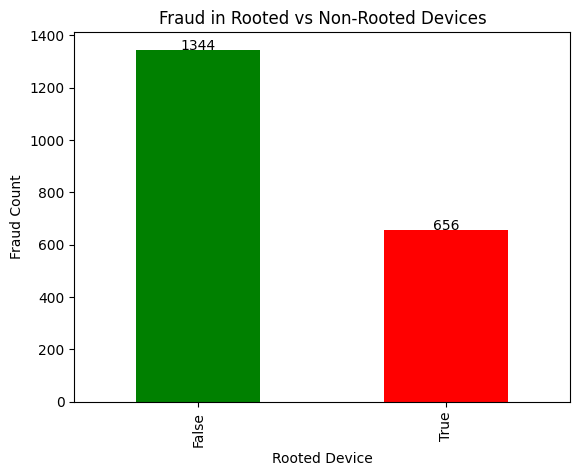

In [68]:
device_fraud = upi_transaction_history.merge(
    device_info,
    on='device_id',
    how='left'
)

rooted_fraud = device_fraud[
    device_fraud['fraud_flag'] == True
]['is_rooted'].value_counts()

ax = rooted_fraud.plot(
    kind='bar',
    color=['green', 'red']
)

plt.title("Fraud in Rooted vs Non-Rooted Devices")

plt.xlabel("Rooted Device")

plt.ylabel("Fraud Count")


for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width()/2,
        i.get_height(),
        int(i.get_height()),
        ha='center'
    )

plt.show()

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>Fraudulent transactions were significantly higher in non-rooted devices (1344) compared to rooted devices (656). However, rooted devices still accounted for a considerable number of fraud cases, indicating that device rooting may contribute to security vulnerabilities and suspicious activities.

This suggests that fraud is not limited to rooted devices alone, and both rooted and non-rooted devices require continuous monitoring and robust security mechanisms.</h4>

</body>
</body></html>



<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
  Monthly Fraud Trend Analysis
</h3>

<h3 style="color: yellow; 
           background-color: gray; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   Visualization Stage
</h3>

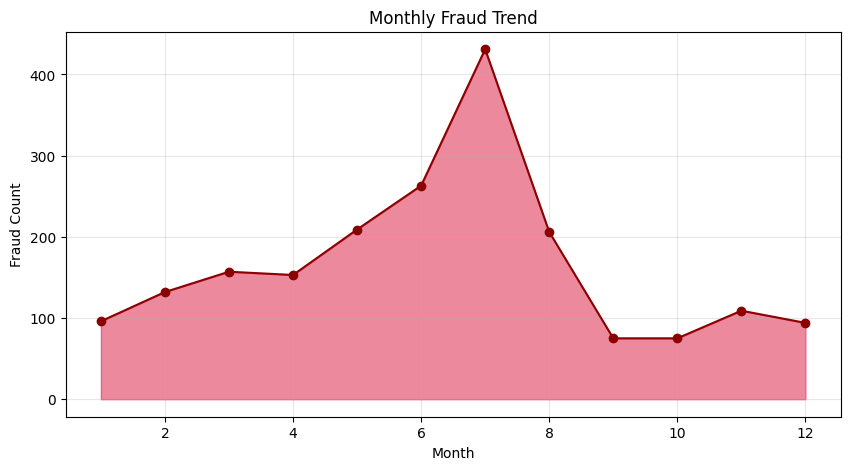

In [74]:
monthly_fraud = upi_transaction_history[
    upi_transaction_history['fraud_flag'] == True
].groupby('transaction_month')[
    'transaction_id'
].count()

plt.figure(figsize=(10,5))

plt.fill_between(
    monthly_fraud.index,
    monthly_fraud.values,
    color='crimson',
    alpha=0.5
)

plt.plot(
    monthly_fraud.index,
    monthly_fraud.values,
    marker='o',
    color='darkred'
)

plt.title("Monthly Fraud Trend")

plt.xlabel("Month")

plt.ylabel("Fraud Count")

plt.grid(alpha=0.3)

plt.show()

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>Fraud activity increased gradually from Month 1 to Month 7, where the highest fraud count was observed. After reaching the peak in Month 7, fraudulent transactions declined sharply during Months 8–10 and remained relatively stable toward the end of the year.

This pattern suggests that fraud incidents may be influenced by seasonal transaction activity, promotional periods, or higher customer engagement during specific months.</h4>

</body>
</body></html>



<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
  Hourly Fraud Pattern
</h3>

<h3 style="color: yellow; 
           background-color: gray; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   Visualization Stage
</h3>

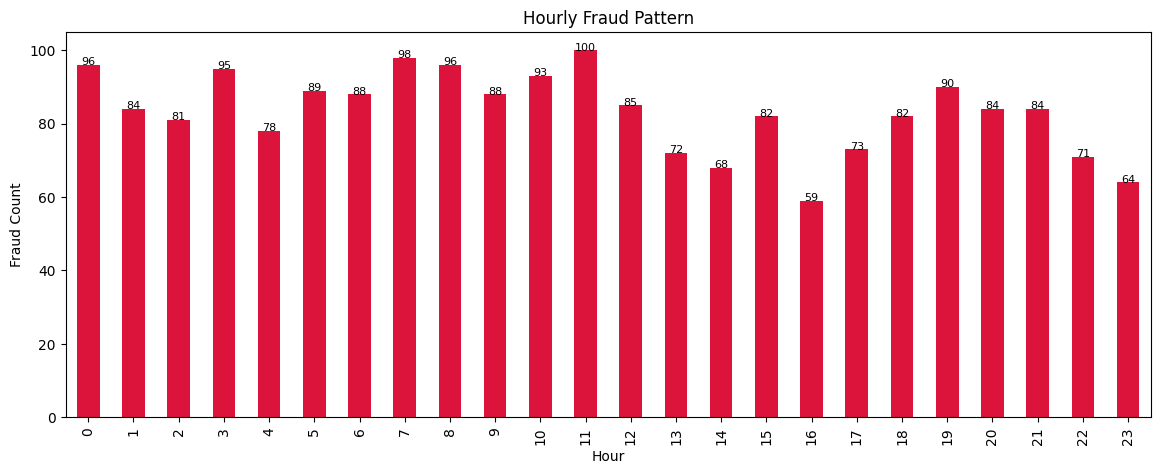

In [73]:
hourly_fraud = upi_transaction_history[
    upi_transaction_history['fraud_flag'] == True
]['transaction_hour'].value_counts().sort_index()

ax = hourly_fraud.plot(
    kind='bar',
    color='crimson',
    figsize=(14,5)
)

plt.title("Hourly Fraud Pattern")

plt.xlabel("Hour")

plt.ylabel("Fraud Count")


for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width()/2,
        i.get_height(),
        int(i.get_height()),
        ha='center',
        fontsize=8
    )

plt.show()

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>Fraud activity remained relatively consistent throughout the day, with slight peaks during certain hours. The highest fraud count was observed around Hour 11, while lower fraud activity was recorded during Hour 16.</h4>

</body>
</body></html>



<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
  Weekday Fraud Pattern
</h3>

<h3 style="color: yellow; 
           background-color: gray; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   Visualization Stage
</h3>

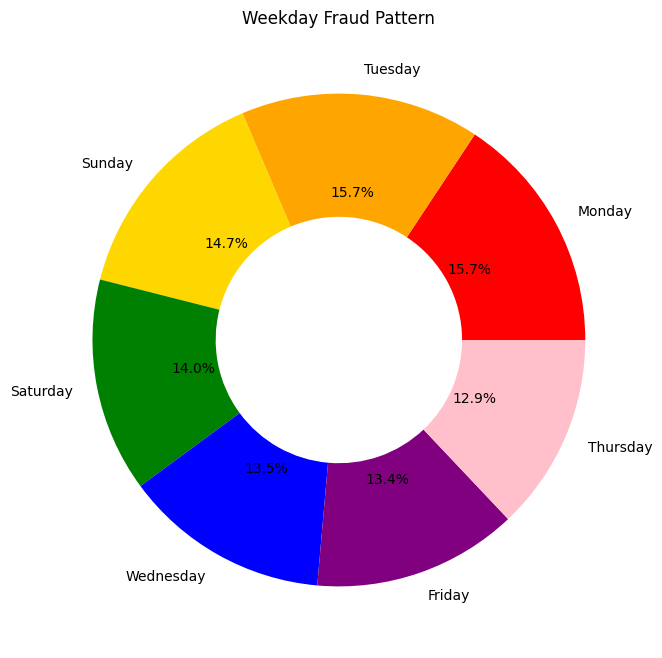

In [72]:
weekday_fraud = upi_transaction_history[
    upi_transaction_history['fraud_flag'] == True
]['transaction_weekday'].value_counts()

colors = [
    'red','orange','gold',
    'green','blue','purple','pink'
]

weekday_fraud.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors,
    wedgeprops={'width':0.5},
    figsize=(8,8)
)

plt.title("Weekday Fraud Pattern")

plt.ylabel("")

plt.show()

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>Fraudulent transactions were fairly evenly distributed across all weekdays, with Monday and Tuesday recording the highest fraud share (15.7% each). Thursday showed comparatively lower fraud activity (12.9%).

This suggests that fraud incidents occur consistently throughout the week rather than being concentrated on a specific day.</h4>

</body>
</body></html>



<h2 style="color: white; 
           background-color: red; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   Statistical Analysis
</h2>

<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
  Descriptive Statistical Analysis
</h3>

<h3 style="color: yellow; 
           background-color: gray; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   Visualization Stage
</h3>

In [ ]:
upi_transaction_history['amount'].describe()

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>The transaction amount distribution shows variation across payment values, with lower-value transactions dominating the overall UPI ecosystem.</h4>

</body>
</body></html>



<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
 Correlation Analysis
</h3>

In [71]:
numeric_cols = [
    'amount',
    'fraud_flag',
    'reversal_flag',
    'transaction_hour'
]

corr_matrix = upi_transaction_history[
    numeric_cols
].corr()

corr_matrix

,amount,fraud_flag,reversal_flag,transaction_hour
amount,1.000000,-0.000256,0.002198,-0.002801
fraud_flag,-0.000256,1.000000,-0.001207,-0.009546
reversal_flag,0.002198,-0.001207,1.000000,-0.000681
transaction_hour,-0.002801,-0.009546,-0.000681,1.000000


<h3 style="color: yellow; 
           background-color: gray; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   Visualization Stage
</h3>

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>The correlation analysis indicates very weak relationships among transaction amount, fraud activity, reversals, and transaction timing. Most correlation values are close to zero, suggesting that fraudulent behavior is influenced by multiple combined factors rather than a single variable.</h4>

</body>
</body></html>



<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
  Fraud vs Legitimate Transaction Amount
</h3>

In [ ]:
upi_transaction_history.groupby(
    'fraud_label'
)['amount'].mean()

<h3 style="color: yellow; 
           background-color: gray; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   Visualization Stage
</h3>

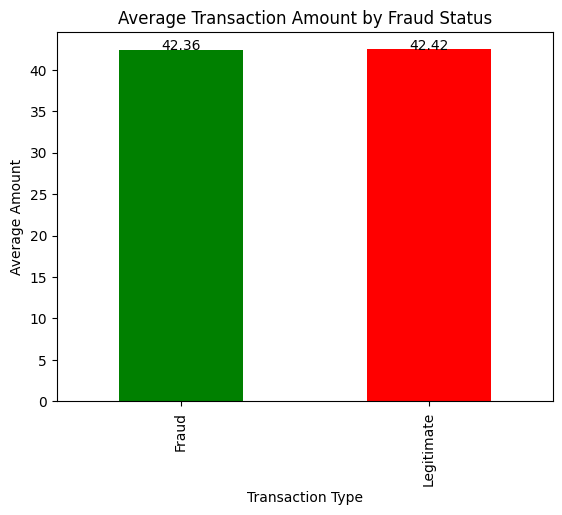

In [70]:
ax = upi_transaction_history.groupby(
    'fraud_label'
)['amount'].mean().plot(
    kind='bar',
    color=['green','red']
)

plt.title("Average Transaction Amount by Fraud Status")

plt.xlabel("Transaction Type")

plt.ylabel("Average Amount")


for i in ax.patches:
    ax.text(
        i.get_x() + i.get_width()/2,
        i.get_height(),
        round(i.get_height(),2),
        ha='center'
    )

plt.show()

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>The average transaction amount for fraudulent and legitimate transactions was almost identical, with fraud transactions averaging 42.36 and legitimate transactions averaging 42.42.

This suggests that transaction amount alone is not a strong indicator of fraud, as fraudulent activities occurred across similar transaction value ranges.</h4>

</body>
</body></html>



<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
  Fraud vs Legitimate Amount Comparison (T-Test)
</h3>

<h3 style="color: yellow; 
           background-color: gray; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   Visualization Stage
</h3>

In [69]:
fraud_amount = upi_transaction_history[
    upi_transaction_history['fraud_flag'] == True
]['amount']

legit_amount = upi_transaction_history[
    upi_transaction_history['fraud_flag'] == False
]['amount']

t_stat, p_value = stats.ttest_ind(
    fraud_amount,
    legit_amount
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.08086970386360601
P-value: 0.9355457356816707


<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>The T-test results show a very high p-value (0.9355), which is much greater than the standard significance level of 0.05. This indicates that there is no statistically significant difference between the average transaction amounts of fraudulent and legitimate transactions.

In simple terms, transaction amount alone does not significantly influence fraud occurrence in the dataset.</h4>

</body>
</body></html>




<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
 Failed Transaction Analysis
</h3>

In [47]:
failed_transactions = upi_transaction_history[
    upi_transaction_history['status'] == 'failed'
]

failed_transactions.shape

(5871, 15)

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>Out of 100,000 total transactions, 5,871 transactions were marked as failed, resulting in a failure rate of approximately 5.87%.

This indicates that the UPI platform maintains a high transaction success rate, but a noticeable number of failed transactions still exist. These failures may be caused by network issues, bank server downtime, device compatibility problems, insufficient balance, or transaction processing errors.

Further analysis by device type, transaction channel, and transaction type can help identify operational bottlenecks and improve transaction reliability.</h4>

</body>
</body></html>






<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
Failed by Device Type
</h3>

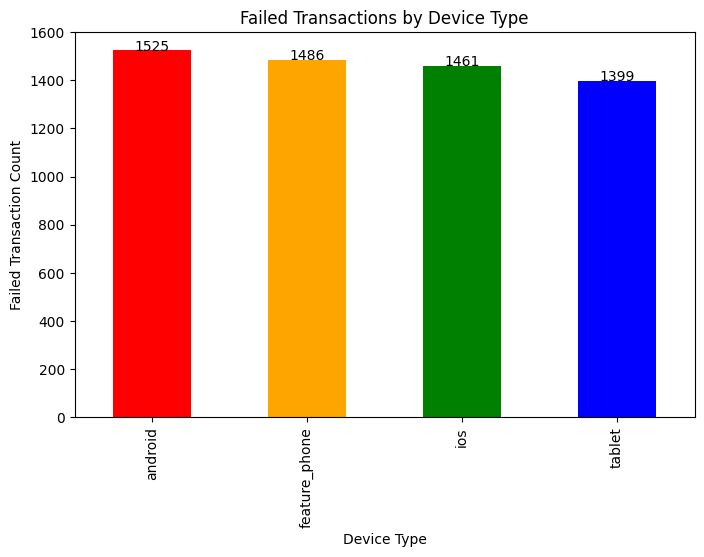

In [20]:
failed_device = failed_transactions['device_type'].value_counts()

ax = failed_device.plot(
    kind='bar',
    color=['red','orange','green','blue'],
    figsize=(8,5)
)

plt.title("Failed Transactions by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Failed Transaction Count")

for i in ax.patches:
    ax.text(i.get_x() + i.get_width()/2, i.get_height(), int(i.get_height()), ha='center')

plt.show()

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>Android devices recorded the highest number of failed transactions (1,525), followed closely by feature phones (1,486), iOS devices (1,461), and tablets (1,399).

The difference in failed transaction counts across device types is relatively small, indicating that transaction failures are not concentrated on a single device category. This suggests that failures may be influenced more by network conditions, banking infrastructure, or transaction processing issues rather than specific device types.

Further investigation into transaction channels, transaction types, and failure reasons is recommended to identify the primary causes of failed transactions and improve overall platform reliability.</h4>

</body>
</body></html>






<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
Failed Transactions by Channel
</h3>

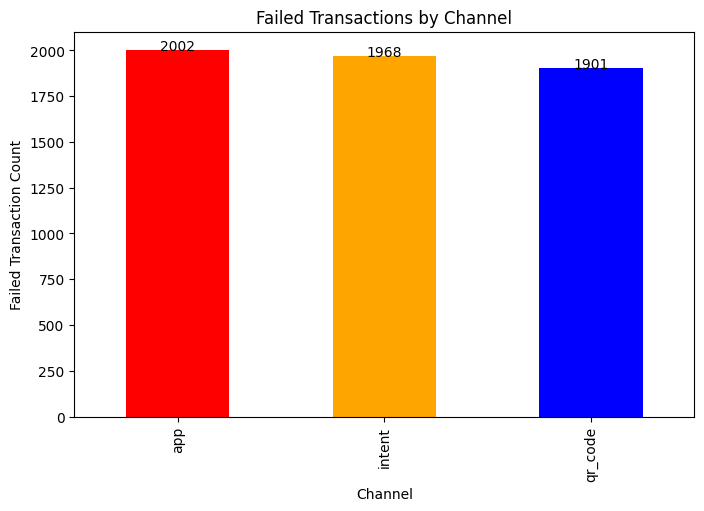

In [75]:
failed_channel = failed_transactions['channel'].value_counts()

ax = failed_channel.plot(
    kind='bar',
    color=['red','orange','blue'],
    figsize=(8,5)
)

plt.title("Failed Transactions by Channel")
plt.xlabel("Channel")
plt.ylabel("Failed Transaction Count")

for i in ax.patches:
    ax.text(i.get_x() + i.get_width()/2, i.get_height(), int(i.get_height()), ha='center')

plt.show()

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>The App channel recorded the highest number of failed transactions (2,002), followed by Intent-based transactions (1,968) and QR Code transactions (1,901).

The difference in failed transaction counts across channels is relatively small, indicating that failures occur across all transaction channels rather than being concentrated in a specific channel. This suggests that operational issues, network connectivity, banking server availability, or transaction processing delays may have a greater impact on failures than the transaction channel itself.

Monitoring channel-specific performance and improving transaction processing infrastructure can help reduce failed transactions and enhance user experience.</h4>

</body>
</body></html>






<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
Failed Transactions by Transaction Type
</h3>

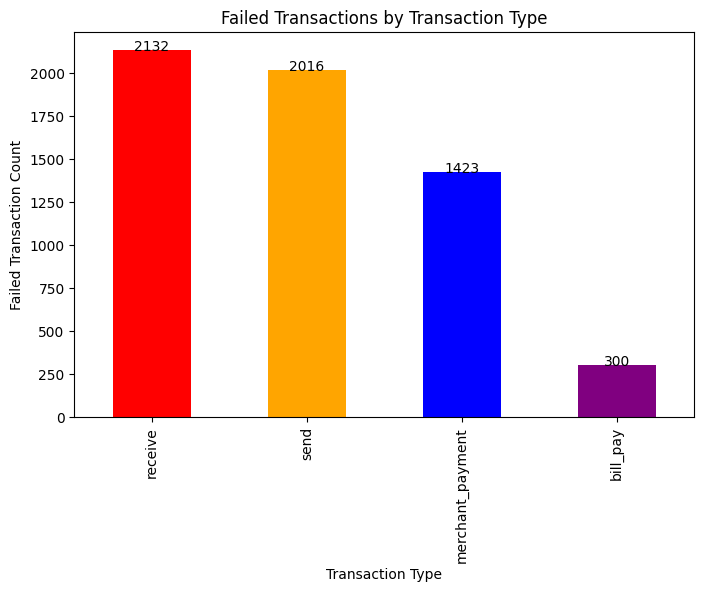

In [76]:
failed_type = failed_transactions['transaction_type'].value_counts()

ax = failed_type.plot(
    kind='bar',
    color=['red','orange','blue','purple'],
    figsize=(8,5)
)

plt.title("Failed Transactions by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Failed Transaction Count")

for i in ax.patches:
    ax.text(i.get_x() + i.get_width()/2, i.get_height(), int(i.get_height()), ha='center')

plt.show()

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>Receive transactions recorded the highest number of failed transactions (2,132), followed closely by Send transactions (2,016). Merchant Payment transactions accounted for 1,423 failures, while Bill Pay transactions showed the lowest failure count (300).

The concentration of failures in Send and Receive transactions indicates that peer-to-peer money transfers experience the highest operational challenges on the platform. Since these transaction types represent the most frequently used UPI services, they naturally contribute to a larger share of failures.

Improving transaction processing, network stability, and bank server coordination for Send and Receive transactions can significantly reduce overall transaction failures and improve customer satisfaction.</h4>

</body>
</body></html>






<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
Top 10 Active Customers
</h3>

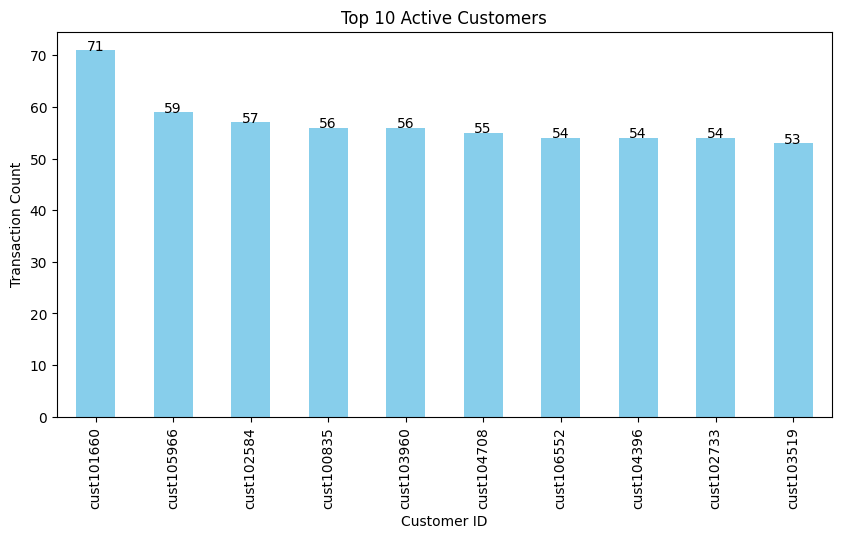

In [77]:
top_customers = (
    upi_transaction_history
    .groupby('customer_id')['transaction_id']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

ax = top_customers.plot(
    kind='bar',
    color='skyblue',
    figsize=(10,5)
)

plt.title("Top 10 Active Customers")
plt.xlabel("Customer ID")
plt.ylabel("Transaction Count")

for i in ax.patches:
    ax.text(i.get_x() + i.get_width()/2, i.get_height(), int(i.get_height()), ha='center')

plt.show()

<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
Top 10 Merchants
</h3>

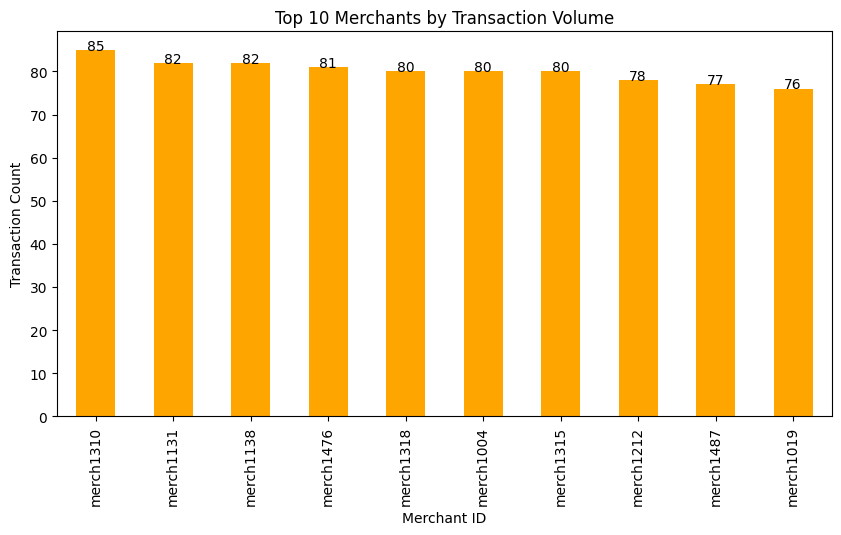

In [81]:
top_merchants = (
    upi_transaction_history
    .dropna(subset=['merchant_id'])
    .groupby('merchant_id')['transaction_id']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

ax = top_merchants.plot(
    kind='bar',
    color='orange',
    figsize=(10,5)
)

plt.title("Top 10 Merchants by Transaction Volume")
plt.xlabel("Merchant ID")
plt.ylabel("Transaction Count")

for i in ax.patches:
    ax.text(i.get_x() + i.get_width()/2, i.get_height(), int(i.get_height()), ha='center')

plt.show()

<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
Customer Feedback Analysis
</h3>

In [82]:
customer_feedback_surveys['satisfaction_score'].value_counts().sort_index()

satisfaction_score
1     332
2     485
3     795
4    1186
5    1202
Name: count, dtype: int64

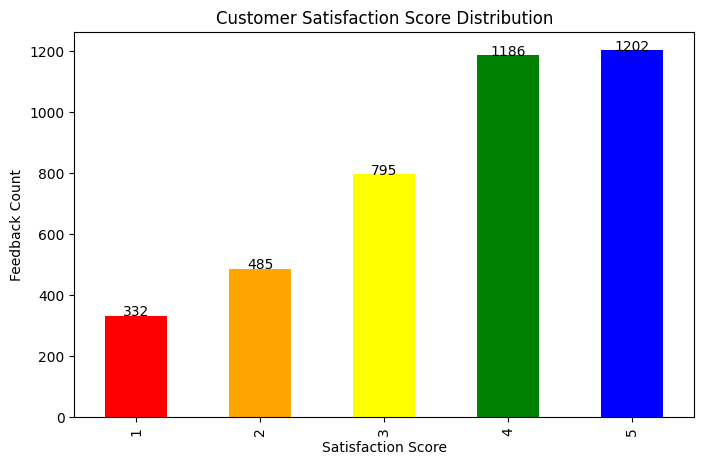

In [83]:
feedback_score = customer_feedback_surveys['satisfaction_score'].value_counts().sort_index()

ax = feedback_score.plot(
    kind='bar',
    color=['red','orange','yellow','green','blue'],
    figsize=(8,5)
)

plt.title("Customer Satisfaction Score Distribution")
plt.xlabel("Satisfaction Score")
plt.ylabel("Feedback Count")

for i in ax.patches:
    ax.text(i.get_x() + i.get_width()/2, i.get_height(), int(i.get_height()), ha='center')

plt.show()

<h4 style="color: white; 
           background-color: blue; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
    Insights
</h4>

<html>
    <body>
<h4>Customer satisfaction scores show a generally positive trend, with the majority of customers providing ratings of 4 and 5. Rating 5 received the highest feedback count (1,202), followed closely by rating 4 (1,186). In contrast, lower ratings such as 1 (332) and 2 (485) were significantly less frequent.

This distribution indicates that most users are satisfied with the UPI platform's performance and services. However, the presence of low ratings suggests that some customers still face issues related to transaction failures, delays, user experience, or support services.

Maintaining service reliability while addressing the concerns of low-rated users can further improve customer satisfaction and platform trust.</h4>

</body>
</body></html>






<h3 style="color: white; 
           background-color: black; 
           font-family: 'Arial black', serif; 
           padding: 20px; 
           border: 5px double red; text-decoration:underline;">
Average Satisfaction Score
</h3>

In [84]:
avg_satisfaction = customer_feedback_surveys['satisfaction_score'].mean()

print("Average Satisfaction Score:", round(avg_satisfaction, 2))

Average Satisfaction Score: 3.61


<h2 style="color: white; 
           background-color: red; 
           font-family: 'Arial black', serif; 
           text-align: center; 
           padding: 20px; 
           border: 5px double red;">
   Conclusion
</h2>

<html>
    <body>
<h4>The UPI Transaction Analysis project successfully examined customer transactions, fraud behavior, device usage, and transaction patterns using Python-based analytics.

The analysis revealed that the majority of UPI transactions were completed successfully, indicating stable platform performance and strong user adoption. Most transactions belonged to lower-value payment ranges, reflecting daily consumer payment behavior.

Fraudulent transactions accounted for only a small percentage of overall activity (~2%), suggesting a relatively secure transaction ecosystem. However, fraud patterns were observed across transaction channels, device types, and transaction categories. QR-code and app-based channels showed comparatively higher fraud activity, while send and receive transaction types recorded the highest fraud counts.

Time-series analysis showed changing transaction and fraud patterns over months, with peak fraud activity observed during Month 7. Hourly and weekday analysis indicated that fraud occurred throughout the day and week without being concentrated in a single time period.

Statistical analysis further revealed weak correlations between fraud, transaction amount, reversals, and transaction timing. T-test results confirmed that transaction amount alone was not a statistically significant factor in distinguishing fraudulent and legitimate transactions.

Overall, the project demonstrates that fraud detection in UPI systems depends on multiple combined factors rather than a single indicator. Continuous monitoring, stronger authentication, and channel-specific fraud prevention mechanisms can help improve transaction security and risk management.</h4>

</body>
</body></html>

